In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from utils import ROOT_PATH
from dataset import BurnoutDataset
from model_factory import Model
from train_model import train_model
from torch.optim import Adam
from dataset import ModelHistory

In [2]:
train_dataset = BurnoutDataset("train")
test_dataset = BurnoutDataset("test")
val_dataset = BurnoutDataset("val")

In [2]:
model = Model([64, 128], [-1, -1], [False, False], [nn.ReLU, nn.ReLU], [False, False], 37, 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [3]:
model, history = train_model(model, 16, 10, 1e-3, 1e-6, Adam, nn.CrossEntropyLoss, device, {
    "accuracy" : accuracy_score
})

100%|██████████| 1500/1500 [00:00<00:00, 2662.33it/s]


In [4]:
print(history.history)

{'train': {'loss': [0.5561232337967424, 0.39297828752951, 0.3200930492361299, 0.2780488318299185, 0.24770842133305723, 0.23396832298666886, 0.21312098066358867, 0.2017543550920309, 0.19429416871531127, 0.18178114973029746], 'accuracy': [0.7669685039370079, 0.8344488188976378, 0.8690944881889764, 0.8858661417322835, 0.8970472440944882, 0.9035433070866141, 0.9111811023622047, 0.9164960629921259, 0.9158661417322834, 0.9234251968503937]}, 'val': {'loss': [0.4421271634399891, 0.39555366267822684, 0.4192848477636774, 0.4513992712087929, 0.47786217054817826, 0.5676731529059664, 0.5404845917161244, 0.5630972700077109, 0.6529614241898526, 0.7305550213404931], 'accuracy': [0.8160416666666667, 0.8877083333333333, 0.876625, 0.86075, 0.8759583333333333, 0.8855416666666667, 0.881875, 0.872125, 0.8854583333333333, 0.8696666666666667]}}


In [7]:
def plot_history(step_name: str, model_history: ModelHistory, max_img_per_width = 3):
    import math
    try:
        metrics_used = model_history.history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(16, h * 8))

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        curr_ax.plot(metrics_used[metric])
        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()




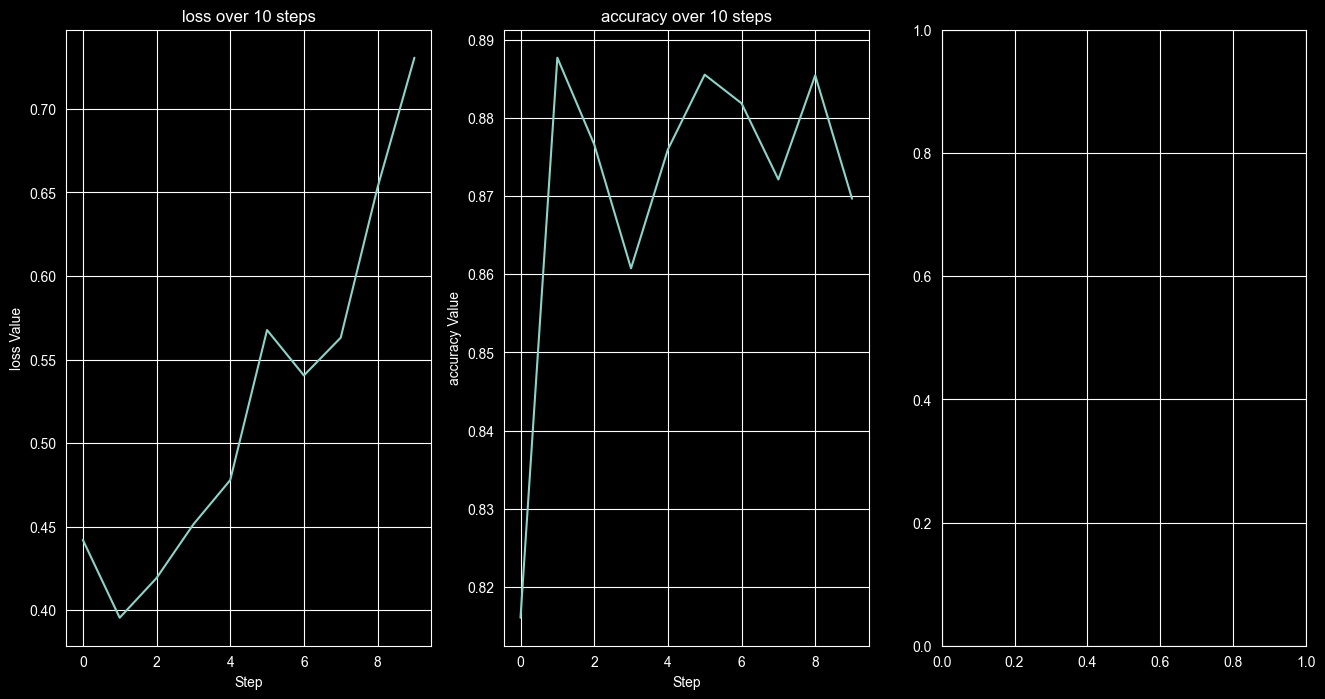

In [9]:
plot_history("val", history)